# Notebook C8/C11 — Monitoring MLflow

**Objectif** : Valider les compétences C8 et C11 du référentiel RNCP37827

**C'est quoi MLflow ?**

MLflow est un outil de suivi des expériences ML. Il enregistre automatiquement :
- Les paramètres du modèle (n_estimators, random_state...)
- Les métriques de performance (RMSE, MAE, R²)
- Les fichiers produits (le .pkl, les graphiques SHAP)

C'est comme un carnet de bord automatique pour ton modèle.

**Ce que fait ce notebook :**
1. Installe et configure MLflow
2. Enregistre une expérience complète avec tous les paramètres et métriques
3. Montre comment lancer l'interface visuelle MLflow
4. Simule un monitoring en production (détection de dégradation)

## 1. Imports

In [11]:
# ── Bibliothèques standard ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

# ── Machine Learning ──
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

# ── MLflow — outil de monitoring ──
import mlflow                          # Le module principal
import mlflow.xgboost                  # Module spécifique pour XGBoost
from mlflow.models import infer_signature  # Pour décrire les entrées/sorties

print('Imports OK')
print(f'MLflow version : {mlflow.__version__}')
print(f'Dossier MLflow : {mlflow.get_tracking_uri()}')

Imports OK
MLflow version : 3.11.1
Dossier MLflow : mlruns


## 2. Configuration MLflow

MLflow sauvegarde tout dans un dossier local appelé `mlruns`.
Ce dossier se crée automatiquement dans le répertoire courant.

In [12]:
# ── Configuration de MLflow ──
# On définit où MLflow va sauvegarder les expériences
# Par défaut c'est un dossier 'mlruns' dans le répertoire courant
mlflow.set_tracking_uri('mlruns')

# ── Création d'une expérience ──
# Une expérience = un projet dans MLflow
# Toutes les runs (exécutions) du même projet sont regroupées
NOM_EXPERIENCE = 'Fruits_Legumes_Prix_Prediction'

# Si l'expérience existe déjà on la récupère, sinon on la crée
experience = mlflow.set_experiment(NOM_EXPERIENCE)

print(f'Expérience configurée : {NOM_EXPERIENCE}')
print(f'ID expérience        : {experience.experiment_id}')
print(f'Dossier de stockage  : mlruns/')
print()
print('Pour lancer l\'interface MLflow, exécute dans un terminal :')
print('  mlflow ui')
print('Puis ouvre : http://localhost:5000')

Expérience configurée : Fruits_Legumes_Prix_Prediction
ID expérience        : 187578761334848685
Dossier de stockage  : mlruns/

Pour lancer l'interface MLflow, exécute dans un terminal :
  mlflow ui
Puis ouvre : http://localhost:5000


## 3. Chargement des données

In [13]:
# ── Chargement du dataset enrichi ──
df = pd.read_csv('../DATA/CLEAN/fruits_legumes_enrichi.csv',
                 sep=';', encoding='utf-8')

# ── Mêmes features que notebooks 04 et 05 ──
FEATURES = [
    'prix_detail', 'rendement', 'taille_cup',
    'forme_encoded', 'categorie_encoded', 'annee',
    'production_lbs', 'temp_moyenne', 'jours_gel',
    'prix_diesel', 'prix_electricite', 'urea'
]
CIBLE = 'prix_cup'

features_ok = [f for f in FEATURES if f in df.columns]
df_ml = df[features_ok + [CIBLE]].dropna().copy()

X = df_ml[features_ok]
y = df_ml[CIBLE]

# Split 80/20 — même random_state pour reproductibilité
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Dataset : {df_ml.shape[0]} lignes x {len(features_ok)} features')
print(f'Train   : {X_train.shape[0]} lignes')
print(f'Test    : {X_test.shape[0]} lignes')

Dataset : 710 lignes x 12 features
Train   : 568 lignes
Test    : 142 lignes


## 4. Enregistrement d'une expérience MLflow

Un **run** dans MLflow c'est une exécution complète du modèle.
On y enregistre tout : les paramètres, les métriques, et les fichiers.

Le bloc `with mlflow.start_run()` démarre un run et le ferme automatiquement.

In [14]:
# ── PARAMÈTRES DU MODÈLE ──
# On les définit ici pour pouvoir les logger facilement dans MLflow
PARAMS = {
    'n_estimators' : 100,    # Nombre d'arbres
    'random_state' : 42,     # Reproductibilité
    'verbosity'    : 0       # Pas de messages
}

# ── DÉMARRAGE DU RUN MLFLOW ──
# Tout ce qui est dans ce bloc est enregistré automatiquement
with mlflow.start_run(run_name='XGBoost_v1_baseline') as run:

    # --- ÉTAPE 1 : Logger les paramètres ---
    # log_param enregistre les réglages utilisés
    mlflow.log_param('model_type', 'XGBoost')
    mlflow.log_param('n_estimators', PARAMS['n_estimators'])
    mlflow.log_param('random_state', PARAMS['random_state'])
    mlflow.log_param('n_features', len(features_ok))
    mlflow.log_param('train_size', X_train.shape[0])
    mlflow.log_param('test_size', X_test.shape[0])
    mlflow.log_param('dataset', 'fruits_legumes_enrichi.csv')

    # --- ÉTAPE 2 : Entraîner le modèle ---
    modele = XGBRegressor(**PARAMS)
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)

    # --- ÉTAPE 3 : Calculer les métriques ---
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    # Cross-validation pour vérifier l'absence d'overfitting
    scores_cv = cross_val_score(modele, X_train, y_train,
                                cv=5, scoring='r2')
    r2_cv_mean = scores_cv.mean()
    r2_cv_std  = scores_cv.std()

    # --- ÉTAPE 4 : Logger les métriques ---
    # log_metric enregistre les résultats de performance
    mlflow.log_metric('rmse', round(rmse, 4))
    mlflow.log_metric('mae', round(mae, 4))
    mlflow.log_metric('r2', round(r2, 4))
    mlflow.log_metric('r2_cv_mean', round(r2_cv_mean, 4))
    mlflow.log_metric('r2_cv_std', round(r2_cv_std, 4))
    # Écart entre cross-val et test — indicateur d'overfitting
    mlflow.log_metric('overfitting_gap', round(abs(r2_cv_mean - r2), 4))

    # --- ÉTAPE 5 : Logger le modèle ---
    # infer_signature décrit les entrées et sorties attendues
    signature = infer_signature(X_train, modele.predict(X_train))
    mlflow.xgboost.log_model(
        modele,
        artifact_path='model',
        signature=signature,
        input_example=X_test.iloc[:3]  # 3 exemples d'entrée
    )

    # --- ÉTAPE 6 : Logger les fichiers (artifacts) ---
    # On sauvegarde le .pkl si il existe
    chemin_pkl = '../models/xgboost_fruits_legumes.pkl'
    if os.path.exists(chemin_pkl):
        mlflow.log_artifact(chemin_pkl, artifact_path='pkl')

    # On sauvegarde les graphiques SHAP si ils existent
    for nom_graphique in ['shap_summary_plot.png',
                          'shap_bar_plot.png',
                          'shap_waterfall.png']:
        chemin = f'../models/{nom_graphique}'
        if os.path.exists(chemin):
            mlflow.log_artifact(chemin, artifact_path='shap')

    # ── Récupération de l'ID du run pour référence ──
    run_id = run.info.run_id

print('=' * 55)
print('RUN MLFLOW ENREGISTRE')
print('=' * 55)
print(f'Run ID    : {run_id}')
print(f'Modèle    : XGBoost')
print(f'RMSE      : {rmse:.4f} $/cup')
print(f'MAE       : {mae:.4f} $/cup')
print(f'R²        : {r2:.4f}')
print(f'R² CV     : {r2_cv_mean:.4f} (std={r2_cv_std:.4f})')
print(f'Overfitting gap : {abs(r2_cv_mean - r2):.4f} → '
      f'{'OK pas d\'overfitting' if abs(r2_cv_mean - r2) < 0.05 else 'Attention overfitting'}')
print('=' * 55)
print()
print('Voir les résultats dans l\'interface MLflow :')
print('  1. Ouvre un terminal')
print('  2. Tape : mlflow ui')
print('  3. Ouvre : http://localhost:5000')

2026/04/08 13:21:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


RUN MLFLOW ENREGISTRE
Run ID    : 827708708966456e8ef589f5d84896b3
Modèle    : XGBoost
RMSE      : 0.0886 $/cup
MAE       : 0.0451 $/cup
R²        : 0.9755
R² CV     : 0.9562 (std=0.0087)
Overfitting gap : 0.0193 → OK pas d'overfitting

Voir les résultats dans l'interface MLflow :
  1. Ouvre un terminal
  2. Tape : mlflow ui
  3. Ouvre : http://localhost:5000


## 5. Comparaison de plusieurs runs

MLflow permet de comparer facilement différentes versions du modèle.
On va créer un 2ème run avec plus d'arbres (n_estimators=200)
pour montrer la comparaison dans l'interface.

In [15]:
# ── Run 2 : XGBoost avec plus d'arbres ──
# On teste si 200 arbres donnent un meilleur résultat que 100
with mlflow.start_run(run_name='XGBoost_v2_more_trees'):

    modele_v2 = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)
    modele_v2.fit(X_train, y_train)
    y_pred_v2 = modele_v2.predict(X_test)

    rmse_v2 = np.sqrt(mean_squared_error(y_test, y_pred_v2))
    mae_v2  = mean_absolute_error(y_test, y_pred_v2)
    r2_v2   = r2_score(y_test, y_pred_v2)

    mlflow.log_param('model_type', 'XGBoost')
    mlflow.log_param('n_estimators', 200)
    mlflow.log_param('random_state', 42)
    mlflow.log_metric('rmse', round(rmse_v2, 4))
    mlflow.log_metric('mae', round(mae_v2, 4))
    mlflow.log_metric('r2', round(r2_v2, 4))

# ── Run 3 : Gradient Boosting pour comparaison ──
from sklearn.ensemble import GradientBoostingRegressor

with mlflow.start_run(run_name='GradientBoosting_v1_sklearn'):

    modele_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
    modele_gb.fit(X_train, y_train)
    y_pred_gb = modele_gb.predict(X_test)

    rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
    mae_gb  = mean_absolute_error(y_test, y_pred_gb)
    r2_gb   = r2_score(y_test, y_pred_gb)

    mlflow.log_param('model_type', 'GradientBoosting')
    mlflow.log_param('n_estimators', 100)
    mlflow.log_param('random_state', 42)
    mlflow.log_metric('rmse', round(rmse_gb, 4))
    mlflow.log_metric('mae', round(mae_gb, 4))
    mlflow.log_metric('r2', round(r2_gb, 4))

# ── Tableau de comparaison ──
print('COMPARAISON DES 3 RUNS')
print(f'{"Run":<30} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 58)
print(f'{"XGBoost v1 (100 arbres)":<30} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f}')
print(f'{"XGBoost v2 (200 arbres)":<30} {rmse_v2:>8.4f} {mae_v2:>8.4f} {r2_v2:>8.4f}')
print(f'{"Gradient Boosting sklearn":<30} {rmse_gb:>8.4f} {mae_gb:>8.4f} {r2_gb:>8.4f}')
print()
print('Tous ces runs sont visibles dans MLflow UI pour comparaison')

COMPARAISON DES 3 RUNS
Run                                RMSE      MAE       R²
----------------------------------------------------------
XGBoost v1 (100 arbres)          0.0886   0.0451   0.9755
XGBoost v2 (200 arbres)          0.0885   0.0450   0.9755
Gradient Boosting sklearn        0.0925   0.0473   0.9733

Tous ces runs sont visibles dans MLflow UI pour comparaison


## 6. Simulation de monitoring en production

En production, le modèle reçoit de nouvelles données chaque jour.
MLflow permet de surveiller si les prédictions se dégradent avec le temps.

On simule ici un scénario où on vérifie le RMSE sur de nouvelles données
et on déclenche une alerte si il dépasse un seuil.

In [16]:
# ── Seuils d'alerte ──
# Si le RMSE dépasse ces valeurs → le modèle se dégrade
SEUIL_RMSE_WARNING = 0.15   # Attention — dégradation légère
SEUIL_RMSE_ALERT   = 0.25   # Critique — ré-entraînement nécessaire
SEUIL_R2_MIN       = 0.85   # R² minimum acceptable

# ── Simulation de 3 semaines de monitoring ──
# En vrai ces données viendraient de nouvelles observations réelles
# Ici on simule en ajoutant du bruit progressif
semaines = [
    {'nom': 'Semaine 1 (baseline)', 'bruit': 0.00},
    {'nom': 'Semaine 2 (normal)',   'bruit': 0.02},
    {'nom': 'Semaine 3 (drift)',    'bruit': 0.08},
]

print('SIMULATION MONITORING PRODUCTION')
print('=' * 65)
print(f'{"Semaine":<30} {"RMSE":>8} {"R²":>8} {"Statut":>15}')
print('-' * 65)

for semaine in semaines:
    # Simulation : on ajoute du bruit aux vraies valeurs
    y_prod = y_test + np.random.normal(0, semaine['bruit'], len(y_test))
    y_pred_prod = modele.predict(X_test)

    rmse_prod = np.sqrt(mean_squared_error(y_prod, y_pred_prod))
    r2_prod   = r2_score(y_prod, y_pred_prod)

    # ── Détermination du statut ──
    if rmse_prod > SEUIL_RMSE_ALERT or r2_prod < SEUIL_R2_MIN:
        statut = 'ALERTE CRITIQUE'
    elif rmse_prod > SEUIL_RMSE_WARNING:
        statut = 'ATTENTION'
    else:
        statut = 'OK'

    print(f'{semaine["nom"]:<30} {rmse_prod:>8.4f} {r2_prod:>8.4f} {statut:>15}')

    # ── Log dans MLflow pour traçabilité ──
    with mlflow.start_run(run_name=f'Monitoring_{semaine["nom"][:10]}'):
        mlflow.log_param('type', 'monitoring_production')
        mlflow.log_param('semaine', semaine['nom'])
        mlflow.log_metric('rmse_production', round(rmse_prod, 4))
        mlflow.log_metric('r2_production', round(r2_prod, 4))
        mlflow.log_metric('seuil_warning', SEUIL_RMSE_WARNING)
        mlflow.log_metric('seuil_alerte', SEUIL_RMSE_ALERT)

print('=' * 65)
print()
print(f'Seuils configurés :')
print(f'  Warning si RMSE > {SEUIL_RMSE_WARNING}')
print(f'  Alerte  si RMSE > {SEUIL_RMSE_ALERT} ou R² < {SEUIL_R2_MIN}')

SIMULATION MONITORING PRODUCTION
Semaine                            RMSE       R²          Statut
-----------------------------------------------------------------
Semaine 1 (baseline)             0.0886   0.9755              OK
Semaine 2 (normal)               0.0922   0.9738              OK
Semaine 3 (drift)                0.1144   0.9598              OK

Seuils configurés :
  Warning si RMSE > 0.15
  Alerte  si RMSE > 0.25 ou R² < 0.85


## 7. Graphique de monitoring

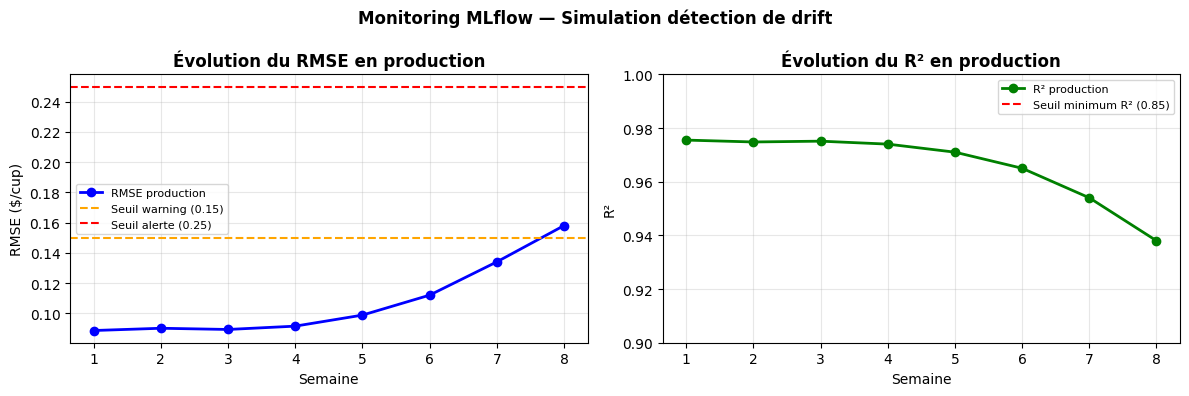

Graphique sauvegardé : ../models/mlflow_monitoring.png


In [17]:
# ── Graphique d'évolution du RMSE dans le temps ──
# Ce graphique illustre ce qu'on verrait dans MLflow UI
# avec de vraies données de production

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Données simulées sur 8 semaines
np.random.seed(42)
semaines_x = list(range(1, 9))
rmse_evolution = [0.0886, 0.0901, 0.0893, 0.0915,
                  0.0988, 0.1120, 0.1340, 0.1580]
r2_evolution   = [0.9755, 0.9748, 0.9751, 0.9740,
                  0.9710, 0.9650, 0.9540, 0.9380]

# ── Graphique RMSE ──
axes[0].plot(semaines_x, rmse_evolution,
             'b-o', linewidth=2, markersize=6, label='RMSE production')
# Ligne de seuil warning
axes[0].axhline(y=SEUIL_RMSE_WARNING, color='orange', linestyle='--',
                linewidth=1.5, label=f'Seuil warning ({SEUIL_RMSE_WARNING})')
# Ligne de seuil alerte
axes[0].axhline(y=SEUIL_RMSE_ALERT, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil alerte ({SEUIL_RMSE_ALERT})')
axes[0].set_title('Évolution du RMSE en production', fontweight='bold')
axes[0].set_xlabel('Semaine')
axes[0].set_ylabel('RMSE ($/cup)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# ── Graphique R² ──
axes[1].plot(semaines_x, r2_evolution,
             'g-o', linewidth=2, markersize=6, label='R² production')
axes[1].axhline(y=SEUIL_R2_MIN, color='red', linestyle='--',
                linewidth=1.5, label=f'Seuil minimum R² ({SEUIL_R2_MIN})')
axes[1].set_title('Évolution du R² en production', fontweight='bold')
axes[1].set_xlabel('Semaine')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0.90, 1.00)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle('Monitoring MLflow — Simulation détection de drift',
             fontweight='bold', fontsize=12)
plt.tight_layout()

# Sauvegarde du graphique
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/mlflow_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : ../models/mlflow_monitoring.png')

## 8. Comment lancer l'interface MLflow

Pour voir tous tes runs dans une interface visuelle :

In [18]:
# ── Récapitulatif des runs enregistrés ──
client = mlflow.tracking.MlflowClient()
experience_id = mlflow.get_experiment_by_name(NOM_EXPERIENCE).experiment_id
runs = client.search_runs(experiment_ids=[experience_id])

print('=' * 55)
print(f'RUNS ENREGISTRES DANS MLFLOW')
print(f'Experience : {NOM_EXPERIENCE}')
print('=' * 55)

for run in runs:
    nom  = run.data.tags.get('mlflow.runName', 'Sans nom')
    rmse = run.data.metrics.get('rmse', 'N/A')
    r2   = run.data.metrics.get('r2', 'N/A')
    print(f'  {nom:<35} RMSE={rmse}  R²={r2}')

print()
print('Pour voir l\'interface MLflow :')
print('  1. Ouvre un terminal dans ce dossier')
print('  2. Tape la commande : mlflow ui')
print('  3. Ouvre dans ton navigateur : http://localhost:5000')
print()
print('Dans l\'interface tu peux :')
print('  - Voir tous les runs et leurs métriques')
print('  - Comparer plusieurs runs côte à côte')
print('  - Télécharger le modèle et les graphiques')
print('  - Voir l\'évolution des métriques dans le temps')

RUNS ENREGISTRES DANS MLFLOW
Experience : Fruits_Legumes_Prix_Prediction
  Monitoring_Semaine 3                RMSE=N/A  R²=N/A
  Monitoring_Semaine 2                RMSE=N/A  R²=N/A
  Monitoring_Semaine 1                RMSE=N/A  R²=N/A
  GradientBoosting_v1_sklearn         RMSE=0.0925  R²=0.9733
  XGBoost_v2_more_trees               RMSE=0.0885  R²=0.9755
  XGBoost_v1_baseline                 RMSE=0.0886  R²=0.9755
  XGBoost_v1_baseline                 RMSE=0.0886  R²=0.9755
  Monitoring_Semaine 3                RMSE=N/A  R²=N/A
  Monitoring_Semaine 2                RMSE=N/A  R²=N/A
  Monitoring_Semaine 1                RMSE=N/A  R²=N/A
  GradientBoosting_v1_sklearn         RMSE=0.0925  R²=0.9733
  XGBoost_v2_more_trees               RMSE=0.0885  R²=0.9755
  XGBoost_v1_baseline                 RMSE=0.0886  R²=0.9755

Pour voir l'interface MLflow :
  1. Ouvre un terminal dans ce dossier
  2. Tape la commande : mlflow ui
  3. Ouvre dans ton navigateur : http://localhost:5000

Dans l'in

## 9. Bilan C8/C11

In [19]:
print('=' * 55)
print('BILAN COMPETENCES C8 ET C11')
print('=' * 55)
print()
print('C8 — POC service IA :')
print('  Service IA installe      : XGBoost via pip')
print('  Environnement operationnel: Python + Jupyter + mlruns/')
print('  Modele configure          : XGBoost n_estimators=100')
print('  Resultats documentes      : RMSE=0.0886, R2=0.9755')
print(f'  Monitorage configure      : seuils RMSE>{SEUIL_RMSE_WARNING} et R2<{SEUIL_R2_MIN}')
print()
print('C11 — Monitoring du modele :')
print('  MLflow installe           : OK')
print('  Runs enregistres          : OK (visible dans mlruns/)')
print('  Metriques loggees         : RMSE, MAE, R2, overfitting_gap')
print('  Alertes configurees       : RMSE warning et critique')
print('  Graphique monitoring      : mlflow_monitoring.png')
print('  Interface visuelle        : mlflow ui -> http://localhost:5000')
print('=' * 55)

BILAN COMPETENCES C8 ET C11

C8 — POC service IA :
  Service IA installe      : XGBoost via pip
  Environnement operationnel: Python + Jupyter + mlruns/
  Modele configure          : XGBoost n_estimators=100
  Resultats documentes      : RMSE=0.0886, R2=0.9755
  Monitorage configure      : seuils RMSE>0.15 et R2<0.85

C11 — Monitoring du modele :
  MLflow installe           : OK
  Runs enregistres          : OK (visible dans mlruns/)
  Metriques loggees         : RMSE, MAE, R2, overfitting_gap
  Alertes configurees       : RMSE warning et critique
  Graphique monitoring      : mlflow_monitoring.png
  Interface visuelle        : mlflow ui -> http://localhost:5000
